In [1]:
#2 - Clean the data
#3 - Split data. Training Set/Test Set
#4 - Create a Model
#5 - Check the output
#6 - Improve

In [3]:
#1 - Import the data
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bryanb/fifa-player-stats-database")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ed5ch\.cache\kagglehub\datasets\bryanb\fifa-player-stats-database\versions\35


In [19]:
import pandas as pd
fifa_2023 =  pd.read_csv(f'{path}/FIFA23_official_data.csv')
fifa_2023

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Real Face,Position,Joined,Loaned From,Contract Valid Until,Height,Weight,Release Clause,Kit Number,Best Overall Rating
0,209658,L. Goretzka,27,https://cdn.sofifa.net/players/209/658/23_60.png,Germany,https://cdn.sofifa.net/flags/de.png,87,88,FC Bayern München,https://cdn.sofifa.net/teams/21/30.png,...,Yes,"<span class=""pos pos28"">SUB","Jul 1, 2018",NaN,2026,189cm,82kg,€157M,8.0,NaN
1,212198,Bruno Fernandes,27,https://cdn.sofifa.net/players/212/198/23_60.png,Portugal,https://cdn.sofifa.net/flags/pt.png,86,87,Manchester United,https://cdn.sofifa.net/teams/11/30.png,...,Yes,"<span class=""pos pos15"">LCM","Jan 30, 2020",NaN,2026,179cm,69kg,€155M,8.0,NaN
2,224334,M. Acuña,30,https://cdn.sofifa.net/players/224/334/23_60.png,Argentina,https://cdn.sofifa.net/flags/ar.png,85,85,Sevilla FC,https://cdn.sofifa.net/teams/481/30.png,...,No,"<span class=""pos pos7"">LB","Sep 14, 2020",NaN,2024,172cm,69kg,€97.7M,19.0,NaN
3,192985,K. De Bruyne,31,https://cdn.sofifa.net/players/192/985/23_60.png,Belgium,https://cdn.sofifa.net/flags/be.png,91,91,Manchester City,https://cdn.sofifa.net/teams/10/30.png,...,Yes,"<span class=""pos pos13"">RCM","Aug 30, 2015",NaN,2025,181cm,70kg,€198.9M,17.0,NaN
4,224232,N. Barella,25,https://cdn.sofifa.net/players/224/232/23_60.png,Italy,https://cdn.sofifa.net/flags/it.png,86,89,Inter,https://cdn.sofifa.net/teams/44/30.png,...,Yes,"<span class=""pos pos13"">RCM","Sep 1, 2020",NaN,2026,172cm,68kg,€154.4M,23.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17655,269526,Deng Xiongtao,19,https://cdn.sofifa.net/players/269/526/23_60.png,China PR,https://cdn.sofifa.net/flags/cn.png,48,61,Meizhou Hakka,https://cdn.sofifa.net/teams/114628/30.png,...,No,"<span class=""pos pos29"">RES","Apr 11, 2022",NaN,2027,190cm,78kg,€218K,35.0,NaN
17656,267946,22 Lim Jun Sub,17,https://cdn.sofifa.net/players/267/946/22_60.png,Korea Republic,https://cdn.sofifa.net/flags/kr.png,48,64,Jeju United FC,https://cdn.sofifa.net/teams/1478/30.png,...,No,"<span class=""pos pos29"">RES","Jan 1, 2022",NaN,2026,195cm,84kg,€188K,21.0,NaN
17657,270567,A. Demir,25,https://cdn.sofifa.net/players/270/567/23_60.png,Turkey,https://cdn.sofifa.net/flags/tr.png,51,56,Ümraniyespor,https://cdn.sofifa.net/teams/113796/30.png,...,No,"<span class=""pos pos29"">RES","Jun 6, 2021",NaN,2023,190cm,82kg,€142K,12.0,NaN
17658,256624,21 S. Czajor,18,https://cdn.sofifa.net/players/256/624/21_60.png,Poland,https://cdn.sofifa.net/flags/pl.png,50,65,Fleetwood Town,https://cdn.sofifa.net/teams/112260/30.png,...,No,"<span class=""pos pos29"">RES","Jan 1, 2020",NaN,2021,187cm,79kg,€214K,40.0,NaN


In [21]:
# Clean the data
fifa_2023_modified = pd.DataFrame(fifa_2023,columns=['Name', 'Wage', 'Value' ])
fifa_2023_modified

,Name,Wage,Value
0,L. Goretzka,€115K,€91M
1,Bruno Fernandes,€190K,€78.5M
2,M. Acuña,€46K,€46.5M
3,K. De Bruyne,€350K,€107.5M
4,N. Barella,€110K,€89.5M
...,...,...,...
17655,Deng Xiongtao,€500,€100K
17656,22 Lim Jun Sub,€500,€100K
17657,A. Demir,€2K,€70K
17658,21 S. Czajor,€500,€90K


In [23]:
def value_to_float(x):
    if type(x) == float or type(x) == int:
        return x
    if 'K' in x:
        if len(x) > 1:
            return float(x.replace('K', '')) * 1000
        return 1000.0
    if 'M' in x:
        if len(x) > 1:
            return float(x.replace('M', '')) * 1000000
        return 1000000.0
    if 'B' in x:
        return float(x.replace('B', '')) * 1000000000
    return 0.0

wage = fifa_2023_modified['Wage'].replace('[\€,]', '', regex=True).apply(value_to_float)
value = fifa_2023_modified['Value'].replace('[\€,]', '', regex=True).apply(value_to_float)
fifa_2023_modified['Wage'] = wage
fifa_2023_modified['Value'] = value

fifa_2023_modified['Difference'] = fifa_2023_modified['Value'] - fifa_2023_modified['Wage']
fifa_2023_modified.sort_values('Difference', ascending=False)



,Name,Wage,Value,Difference
75,K. Mbappé,230000.0,190500000.0,190270000.0
180,E. Haaland,220000.0,148000000.0,147780000.0
17,F. de Jong,230000.0,116500000.0,116270000.0
214,Pedri,115000.0,116000000.0,115885000.0
25,M. Salah,270000.0,115500000.0,115230000.0
...,...,...,...,...
8455,14 Índio,20000.0,0.0,-20000.0
2031,14 J. Zanetti,45000.0,1000.0,-44000.0
199,R. Kent,45000.0,0.0,-45000.0
1287,14 R. Giggs,60000.0,1000.0,-59000.0


<Axes: xlabel='Wage', ylabel='Value'>

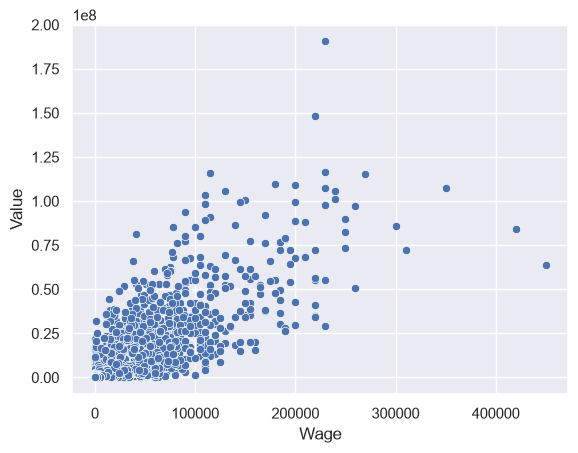

In [24]:
import seaborn as sns
sns.set()

graph = sns.scatterplot(x='Wage', y='Value', data=fifa_2023_modified)
graph

In [27]:
from bokeh.plotting import figure, show
from bokeh.models import HoverTool

hover = HoverTool(tooltips=[
    ("index", "$index"),
    ("(Wage, Value)", "(@Wage, @Value)"),
    ("Name", "@Name")]
)
p = figure(title='FIFA 2023', x_axis_label='wage', y_axis_label='value', tools=[hover])
p.circle('Wage', 'Value', size=10, source=fifa_2023_modified)
show(p)